# Spain–Argentina 2026 World Cup Final: Polymarket event study

This is a compact, exploratory study of the one-second top-of-book record. It answers *when* logically related markets appeared to receive match information, how durable those moves were, and whether liquidity or probability coherence changed around them.

**Safety:** the helper opens SQLite with `mode=ro&immutable=1`; every database statement in this notebook is a `SELECT`. The full 1.44m-row table is never loaded—only 14 token series from seven core markets are selected.

## Event-clock caveat and sources

The minute-level event anchors came from the [FotMob ticker](https://www.fotmob.com/en/matches/spain-vs-3adef/5qgsu1iu#4653858:tab=ticker), with the decisive sequence cross-checked against [FIFA's match report](https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/articles/spain-argentina-final-report-highlights), [AP](https://apnews.com/article/fccc26aa12d9226e63d06b601b770617), [El País](https://elpais.com/deportes/mundial-futbol/2026-07-19/espana-argentina-en-directo-la-final-del-mundial-en-vivo.html), and [Al Jazeera](https://www.aljazeera.com/sports/2026/7/20/key-takeaways-from-the-world-cup-2026-final-as-spain-beat-argentina). Reporting confirms the 90+2 red card, 96' disallowed Williams goal, and 106' Torres winner.

Public minute labels are not synchronized exchange timestamps. The code therefore searches broad UTC windows and defines an **inferred information-arrival second** as the largest robust, synchronized midpoint move within the window. It is evidence of market reaction, not a claim about when the on-pitch event occurred or a proof of causality.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

EXPERIMENT_DIR = (Path.cwd() / 'final' / '01-experiment').resolve()
if not EXPERIMENT_DIR.exists():
    EXPERIMENT_DIR = (Path.cwd() / '01-experiment').resolve()
sys.path.insert(0, str(EXPERIMENT_DIR))

from data_access import CORE_MARKETS, connect_readonly, load_market_panel, recording_bounds
from event_detection import detect_event_arrivals, event_window, make_feature_panel
from event_timeline import SOURCES, timeline_frame
from metrics import event_response_table, lead_lag_table, regulation_probability_diagnostic
from models import lagged_pair_regression
from plots import plot_event_midpoints, plot_lead_lag, plot_probability_diagnostic

pd.set_option('display.max_colwidth', 110)
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
# One SQL-filtered read: seven core markets × two outcomes, not all 98 tokens.
with connect_readonly() as conn:
    coverage = recording_bounds(conn)
    panel = load_market_panel(conn)

print('Core panel rows:', f'{len(panel):,}')
coverage.to_frame().T

Core panel rows: 205,380


,first_timestamp_utc,last_timestamp_utc,snapshot_rows
0,2026-07-19T17:59:37.094+00:00,2026-07-19T22:04:10.890+00:00,1437660


In [4]:
panel[['market_key', 'market_id', 'market_question', 'outcome', 'token_id']].drop_duplicates().sort_values(['market_key', 'outcome'])

,market_key,market_id,market_question,outcome,token_id
4,argentina_regulation,2941976,Will Argentina win on 2026-07-19?,NO,40285215796521673925483410143614666389701053711161542152061618519144468632440
5,argentina_regulation,2941976,Will Argentina win on 2026-07-19?,YES,22596903656102431101396261359922941848858035376971300420659017295333613251025
12,both_teams_score,2945083,Spain vs. Argentina: Both Teams to Score,NO,26086477339270164470484984523102108367508939325488072884563308690155488440387
13,both_teams_score,2945083,Spain vs. Argentina: Both Teams to Score,YES,43400327584658432314631806325041229967848913385037627203899950879363399512175
2,draw_regulation,2941975,Will Spain vs. Argentina end in a draw?,NO,8897745942892740554419142821188087932128583924929997823029754125155949675043
3,draw_regulation,2941975,Will Spain vs. Argentina end in a draw?,YES,92571123127402723974640575698896369187398878096159854165218788690275715186568
10,extra_time,2942084,Spain vs. Argentina: Will the Match Go to Extra Time?,NO,45064127349620505638971408853930687190941379805009611444184929924545684192288
11,extra_time,2942084,Spain vs. Argentina: Will the Match Go to Extra Time?,YES,97948501642772411011659953242528615488160007717513876997441328473821772128256
6,over_0_5,2942074,Spain vs. Argentina: O/U 0.5,NO,100899066788087264896991245177978653395891419153169248929857538839728453964270
7,over_0_5,2942074,Spain vs. Argentina: O/U 0.5,YES,95825958363807846699086525334115004140149075455134418888294284834103444139805


In [5]:
timeline = timeline_frame()
timeline[['minute', 'label', 'event_type', 'start_utc', 'end_utc', 'note']]

,minute,label,event_type,start_utc,end_utc,note
0,0',Kickoff,structural,2026-07-19 18:58:00+00:00,2026-07-19 19:04:00+00:00,Opening whistle / market transition from pre-match.
1,6',Messi early chance,ambiguous,2026-07-19 19:03:00+00:00,2026-07-19 19:13:00+00:00,Important Argentina chance reported around the sixth minute.
2,45',Halftime,structural,2026-07-19 19:42:00+00:00,2026-07-19 19:57:00+00:00,Scoreless first half; reporting notes an extended halftime show.
3,46',Second-half kickoff,structural,2026-07-19 20:10:00+00:00,2026-07-19 20:27:00+00:00,Wide window accommodates the unusually long halftime interval.
4,90+2',Enzo Fernández red card,definitive,2026-07-19 20:57:00+00:00,2026-07-19 21:14:00+00:00,Argentina reduced to ten at the end of normal time.
5,96',Williams goal disallowed,ambiguous,2026-07-19 21:08:00+00:00,2026-07-19 21:27:00+00:00,Spain briefly appeared to score; the goal was disallowed.
6,106',Torres winning goal,definitive,2026-07-19 21:18:00+00:00,2026-07-19 21:39:00+00:00,Ferran Torres scored Spain's 1-0 extra-time winner.
7,120+',Full time,structural,2026-07-19 21:38:00+00:00,2026-07-19 22:00:00+00:00,Final whistle and transition to post-match settlement.


In [6]:
midpoint, top_size = make_feature_panel(panel)
arrivals = detect_event_arrivals(midpoint, timeline)
arrivals[['minute', 'label', 'event_type', 'arrival_utc', 'synchronized_score', 'markets_moving', 'mean_abs_change']].round(4)

C:\Users\eliis\AppData\Local\Temp\ipykernel_46556\2788813003.py:3: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  arrivals[['minute', 'label', 'event_type', 'arrival_utc', 'synchronized_score', 'markets_moving', 'mean_abs_change']].round(4)


,minute,label,event_type,arrival_utc,synchronized_score,markets_moving,mean_abs_change
0,0',Kickoff,structural,2026-07-19 19:00:11.867000+00:00,21.0000,4.0,0.0111
1,6',Messi early chance,ambiguous,2026-07-19 19:12:00.865000+00:00,24.5000,8.0,0.0295
2,45',Halftime,structural,2026-07-19 19:44:29.867000+00:00,31.0000,8.0,0.0111
3,46',Second-half kickoff,structural,2026-07-19 20:25:07.866000+00:00,21.0000,4.0,0.0132
4,90+2',Enzo Fernández red card,definitive,2026-07-19 21:09:56.869000+00:00,57.2000,12.0,0.0244
5,96',Williams goal disallowed,ambiguous,2026-07-19 21:09:56.869000+00:00,57.6667,12.0,0.0244
6,106',Torres winning goal,definitive,2026-07-19 21:26:24.873000+00:00,20.0000,2.0,0.0825
7,120+',Full time,structural,2026-07-19 21:42:28.873000+00:00,20.0000,2.0,0.2388


### Reading the inferred seconds

For this record, the strongest candidates include 19:00:11 UTC near kickoff, 19:44:29 near halftime, 21:09:56 in both the red-card and disallowed-goal windows, 21:26:24 for the winner, and 21:42:28 near full time. The same 21:09:56 candidate in overlapping red-card/disallowed-goal windows is a useful negative result: price data alone cannot assign that burst cleanly to either public event.

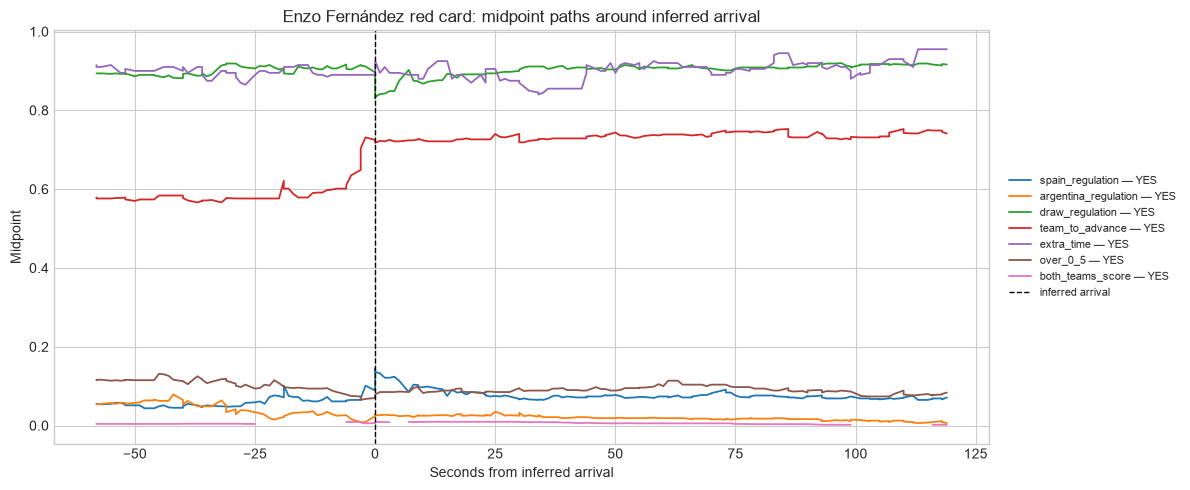

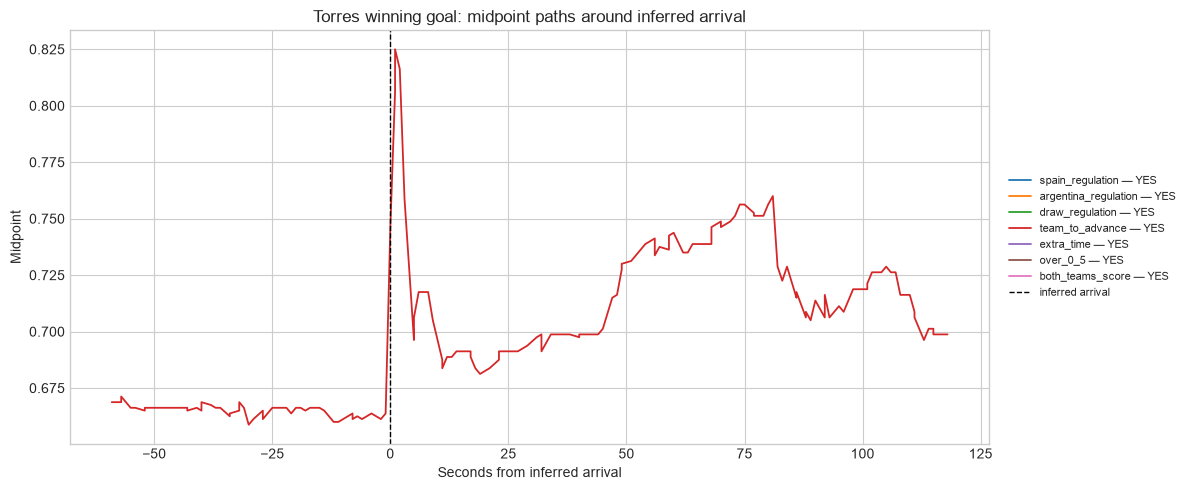

In [7]:
display_series = [
    'spain_regulation — YES', 'argentina_regulation — YES', 'draw_regulation — YES',
    'team_to_advance — YES', 'extra_time — YES', 'over_0_5 — YES', 'both_teams_score — YES',
]
for event_id in ['red_card', 'winning_goal']:
    event = arrivals.loc[arrivals.event_id.eq(event_id)].iloc[0]
    window = event_window(midpoint, event.arrival_utc, seconds_before=60, seconds_after=120)
    plot_event_midpoints(window, f"{event.label}: midpoint paths around inferred arrival", display_series)
    plt.show()

In [8]:
responses = event_response_table(midpoint, top_size, arrivals)
type_summary = (responses[responses.event_type.isin(['ambiguous', 'definitive'])]
    .groupby('event_type')[['peak_abs_midpoint_change', 'reversal_ratio', 'top_size_change_pct']]
    .median().rename(columns={
        'peak_abs_midpoint_change': 'median_peak_abs_change',
        'reversal_ratio': 'median_reversal_ratio',
        'top_size_change_pct': 'median_top_size_change_pct',
    }))
type_summary.round(3)

,median_peak_abs_change,median_reversal_ratio,median_top_size_change_pct
event_type,,,
ambiguous,0.012,0.701,84.753
definitive,0.066,0.526,12.767


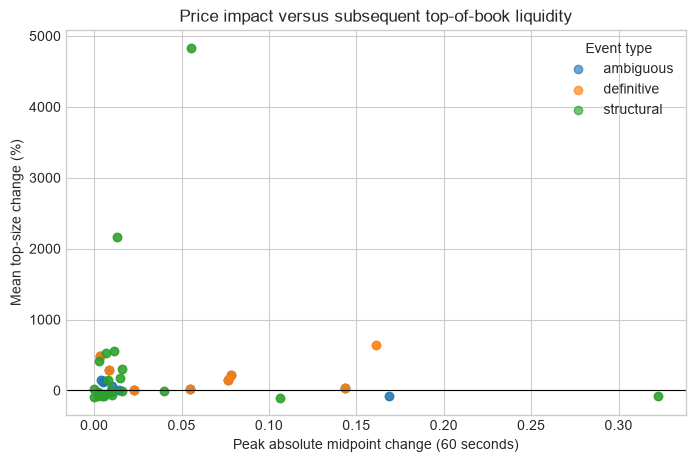

C:\Users\eliis\AppData\Local\Temp\ipykernel_46556\137704023.py:9: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  responses[responses.event_id.isin(['red_card', 'disallowed_goal', 'winning_goal'])].sort_values(['event_id', 'peak_abs_midpoint_change'], ascending=[True, False]).head(18).round(3)


,event_id,label,event_type,arrival_utc,series,peak_abs_midpoint_change,end_midpoint_change,reversal_ratio,top_size_change_pct
82,disallowed_goal,Williams goal disallowed,ambiguous,2026-07-19 21:09:56.869000+00:00,team_to_advance — NO,0.143,-0.136,0.052,35.381
83,disallowed_goal,Williams goal disallowed,ambiguous,2026-07-19 21:09:56.869000+00:00,team_to_advance — YES,0.143,0.136,0.052,35.381
81,disallowed_goal,Williams goal disallowed,ambiguous,2026-07-19 21:09:56.869000+00:00,spain_regulation — YES,0.078,0.007,0.908,212.193
80,disallowed_goal,Williams goal disallowed,ambiguous,2026-07-19 21:09:56.869000+00:00,spain_regulation — NO,0.078,-0.007,0.908,212.193
74,disallowed_goal,Williams goal disallowed,ambiguous,2026-07-19 21:09:56.869000+00:00,draw_regulation — NO,0.077,-0.001,0.990,148.360
75,disallowed_goal,Williams goal disallowed,ambiguous,2026-07-19 21:09:56.869000+00:00,draw_regulation — YES,0.077,0.001,0.990,148.360
77,disallowed_goal,Williams goal disallowed,ambiguous,2026-07-19 21:09:56.869000+00:00,extra_time — YES,0.055,0.025,0.541,13.397
76,disallowed_goal,Williams goal disallowed,ambiguous,2026-07-19 21:09:56.869000+00:00,extra_time — NO,0.055,-0.025,0.541,13.397
78,disallowed_goal,Williams goal disallowed,ambiguous,2026-07-19 21:09:56.869000+00:00,over_0_5 — NO,0.023,-0.012,0.453,12.137
79,disallowed_goal,Williams goal disallowed,ambiguous,2026-07-19 21:09:56.869000+00:00,over_0_5 — YES,0.023,0.012,0.453,12.137


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for kind, group in responses.groupby('event_type'):
    ax.scatter(group['peak_abs_midpoint_change'], group['top_size_change_pct'], alpha=0.65, label=kind)
ax.axhline(0, color='black', linewidth=0.8)
ax.set(title='Price impact versus subsequent top-of-book liquidity', xlabel='Peak absolute midpoint change (60 seconds)', ylabel='Mean top-size change (%)')
ax.legend(title='Event type')
plt.show()

responses[responses.event_id.isin(['red_card', 'disallowed_goal', 'winning_goal'])].sort_values(['event_id', 'peak_abs_midpoint_change'], ascending=[True, False]).head(18).round(3)

The median response supports a simple interpretation: ambiguous windows had smaller initial moves (about 1.2¢ in the core series) but more reversal (about 70%) than definitive windows (about 6.6¢ and 53% reversal). This is descriptive rather than a formal test—there are only a few heterogeneous match events—but it is consistent with a market initially pricing uncertainty and then unwinding it.

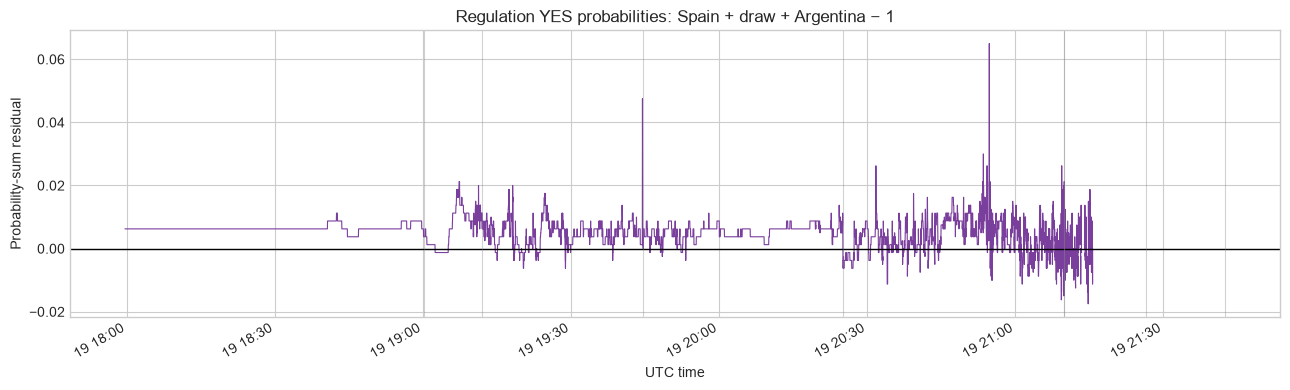

0.50    0.00625
0.90    0.00875
0.99    0.01625
Name: absolute_probability_sum_error, dtype: float64

In [10]:
regulation = regulation_probability_diagnostic(panel)
plot_probability_diagnostic(regulation, arrivals)
plt.show()

regulation['sum_minus_one'].abs().quantile([0.50, 0.90, 0.99]).rename('absolute_probability_sum_error')

The three regulation YES midpoints are usually coherent: the median absolute Spain + draw + Argentina residual is about 0.63¢ and the 99th percentile about 1.62¢. These are temporary quote-level discrepancies, not automatically executable arbitrage after sizes, fees, and latency.

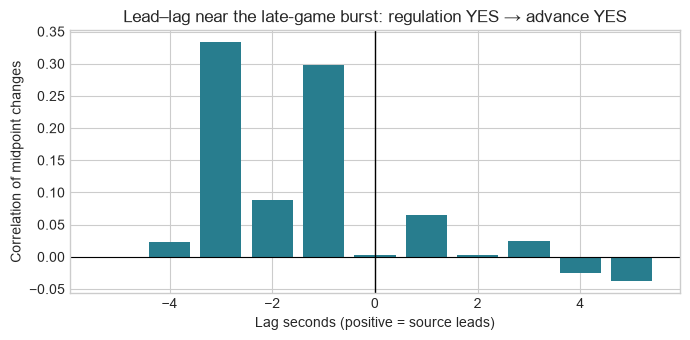

,lag_seconds,correlation,n
0,-5,0.000,175
1,-4,0.023,176
2,-3,0.333,177
3,-2,0.088,178
4,-1,0.298,179
5,0,0.003,180
6,1,0.066,179
7,2,0.002,178
8,3,0.024,177
9,4,-0.025,176


In [11]:
# Use the red-card/disallowed-goal burst, when both series were still live.
source = 'spain_regulation — YES'
target = 'team_to_advance — YES'
red_arrival = arrivals.loc[arrivals.event_id.eq('red_card'), 'arrival_utc'].iloc[0]
lead_lag = lead_lag_table(midpoint, source, target, red_arrival, radius_seconds=90, max_lag=5)
plot_lead_lag(lead_lag, 'Lead–lag near the late-game burst: regulation YES → advance YES')
plt.show()
lead_lag.round(3)

In [12]:
# A small descriptive regression, limited to distinct pre-resolution event windows.
pre_resolution = arrivals.loc[arrivals.arrival_utc <= red_arrival].drop_duplicates('arrival_utc')
regression = lagged_pair_regression(midpoint, source, target, pre_resolution, radius_seconds=90)
regression.round(4)

,term,coefficient,std_error,t_stat,n,r_squared
0,intercept,0.0001,0.0001,1.1169,895,0.0072
1,source_change_t,-0.0079,0.0268,-0.2948,895,0.0072
2,source_change_t_minus_1,0.0217,0.0263,0.8273,895,0.0072
3,target_change_t_minus_1,0.0815,0.0341,2.3923,895,0.0072


The lag plot and OLS table are deliberately modest. They show association in sampled quote changes—not price discovery, causality, or tradable lead. At the late burst the largest correlation is contemporaneous/near-contemporaneous, and in the small lagged regression the target's own lag is materially stronger than the source's lag. That is more consistent with joint reaction and microstructure persistence than a stable one-second leader.

## Conclusions

1. The data isolate plausible market-information seconds despite an unsynchronized public clock; the 106' winner produces a distinct later reaction, while the red card and disallowed-goal window cannot be separated cleanly.
2. Definitive events created larger and more persistent repricing than ambiguous events, while the latter showed more reversal.
3. Top-of-book liquidity did not move uniformly: it expanded around some uncertainty bursts and was roughly flat around the winner in the aggregate. Quote availability therefore matters when reading midpoints.
4. The regulation probability triangle stayed tight most of the time. Its short-lived residuals are a diagnostic of asynchronous quotes, not a trading claim.
5. The compact lead–lag/regression checks support synchronized reaction and autoregressive quote updating, not a robust one-second causal hierarchy. A richer study would need independently timestamped video/event feeds and executable depth/fee data.